**Informations de groupe - Prénoms et noms complets:**

- Jeremy Bortone
- Kilian Stockinger
- Candas Kat

**Professeurs**: Carlos Peña et Stephan Robert

**Assistant(s)**: Thibault Schowing, Arthur Babey, Cédric Campos Carvalho

**Contact**: prenom.nom@heig-vd.ch ou de préférence via Teams 

### Modalités de rendu :

- **Date**: <span style="background-color:#eebbdd">30.11.2025, 23h55</span>


- **Travail par groupe** de 2 ou 3. 


- Une fois complété, rendez directement le notebook (fichier avec l'extension _.ipynb_) nommé correctement comme suit <span style="background-color:#eebbdd">"**TP3_ISD_SA2025_Nom1_Nom2(_Nom3).ipynb**"</span> en mettant les noms de famille de chaque membres du groupe (pour ceux avec plusieurs noms de famille, vous pouvez mettre juste le premier comme dans l'adresse email). Les TPs rendu avec un fichier mal nommé seront pénalisé !


- Mettez vos Prénoms et noms en entier ci-dessus. 


- Uploadez le fichier complété avant le délais sur Cyberlearn ou Teams selon les consignes données. 



### Déroulement et notation


<div class="alert alert-block alert-info">
    <b>Les questions</b> sont généralement indiquées en <b>gras</b>, en <span style="background-color:#AFEEEE">bleu</span> ou par une liste d'instructrions et les endroits où répondre sont indiqués par un "<i>Réponse:</i>" pour les réponses textuelles. Pour les réponses nécessitant d'écrire du code, les cellules ont déjà été crées et un commentaire indique où/quoi répondre. 
</div>


<div class="alert alert-block alert-info">
    <b>Notation: </b> Ce TP est noté sur 6 avec un total de  <span style="background-color:#eebbdd"><b>80</b></span> points. Les points sont indiqués pour chaques parties du travail pour un total de <span style="background-color:#eebbdd"><b>76</b></span> points  et <span style="background-color:#eebbdd"><b>4</b></span> points supplémentaires sont attribués au rendu du travail (format et nommage selon les consignes) et à la propreté (lisibilité et mise en page, tournure de phrase des réponses). 
</div>


<div class="alert alert-block alert-info">
<b>Corrections: </b> Ce notebook vous sera renvoyé via Cyberlearn/Teams ou un autre canal. Les informations principales concernant les corrections seront indiquées après chaque section (banière bleue) avec le nombre de points obtenus. Il est possible que des remarques concernant le code soient directement ajoutées dans celui-ci.
</div>

---


<div class="alert alert-block alert-success">
<b>Objectifs </b>
</div>

- Comprendre la modélisation avec un modèle simple: le modèle à base de règles
- Analyse des résultats avec la matrice de confusion
- Algorithme kNN
- Évaluation des performances avec Validation hold-out et N-Fold Crossvalidation. 

<div class="alert alert-block alert-info">
<b>Aide </b>
</div>

N'oubliez pas que vous pouvez retourner vers les TPs précédents si vous avez des questions sur Python, Numpy, Pandas ou Matplotlib. Gardez vos cheatsheets à proximité !

- [Data wrangling with Pandas](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)
- [Matplotlib cheatscheets](https://matplotlib.org/cheatsheets/)

<div class="alert alert-block alert-info">
<b>N'hésitez pas à écrire à vos assistants directement sur Teams en cas de question.  </b>
</div>



---

### Table des matières<a name="toc"></a>


[Partie 1: Modèle à base de règles](#Part1)

[- 1.1 Analyse exploratoire](#Part11)

[- 1.2 Boxplots, pairplot et choix des variables](#Part12)     ---    [20 points](#Part112pts)

[- 1.3 Création du modèle à base de règles](#Part13)

[- 1.4 Matrice de confusion](#Part14)     ---    [16 points](#Part134pts)

---

[Partie 2: L'algorithme des k plus proches voisins (k-NN) ](#Part2)  

[- 2.1 Implémentation](#Part21)    ----    [12 points](#Part21pts)

[- 2.2 Validation hold-out](#Part22)    ----    [10 points](#Part22pts)

[- 2.3 N-Folds Cross Validation](#Part23)    ----    [10 points](#Part23pts)

[- 2.4 Conclusion](#Part24)    ----    [8 points](#Part24pts)



---

<p style="background-color:#7ba3e3;padding:10px"><font size="6"><b></b></font></p>

---


In [1]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from math import sqrt
import itertools

# Package scikit-learn
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Pour k-NN
from collections import Counter, defaultdict

# Pour validation hold-out

import random
from random import randrange
random.seed(10)

import warnings
warnings.filterwarnings('ignore')

# To show all the rows in jupiter
#pd.set_option('display.max_rows', None)

---


## Partie 1 - Modèle à base de règles<a name="Part1"></a>

[Table des matières](#toc)

[- 1.1 Analyse exploratoire](#Part11)

[- 1.2 Boxplots, pairplot et choix des variables](#Part12)     ---    [20 points](#Part112pts)

[- 1.3 Création du modèle à base de règles](#Part13)

[- 1.4 Matrice de confusion](#Part14)     ---    [16 points](#Part134pts)

Dans cette partie, nous allons créer un modèle de classification simple. 


---
<a name="Part11"></a>
### 1.1 Analyse exploratoire

[Début partie 1](#Part1) --- [Table des matières](#toc)

Nous allons utiliser la base de données «Wine Data Set » disponible sur le dépôt de bases de données maintenu par l’Université de Californie à Irvine (UCI). Le lien est celui-ci : [http://archive.ics.uci.edu/ml/datasets/Wine?Quality].

Créez un DataFrame à partir du fichier **wine.data** et des noms de colonnes fournis, puis explorez rapidement les données. Ouvrez rapidement le fichier et observez les données pour voir leur structure et mieux comprendre la suite et posez-vous ces questions (pas besoin de noter une réponse): 

- *De quel manière sont stockées les données ?* 
- *Pourquoi on nous donne une liste de noms de colonne ?*

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Exercice </b></font> Chargez les données comme indiqué ci-dessous. Si vous le voulez vous pouvez directement charger ces données depuis Scikit-learn, à vous de trouver comment faire.</p>
(2 points)



Notes:

- Utilisez la fonction read_csv() pour lire le fichier **wine.data** et spécifiez le paramètre *names* en lui passant la liste donnée ci-dessous.
- La fonction [_unique()_](https://pandas.pydata.org/docs/reference/api/pandas.unique.html) peut vous être utile !

In [2]:
# Noms de colonnes 

headers = ['Class', 'Alcool', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 
           'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 
           'Hue', 'OD280/OD315 of diluted wines', 'Proline']

# Créez le dataset et nommez le "wines"
# Ajoutez votre code ici.

wines = pd.read_csv('wine.data', names=headers)

wines.sort_values('Alcool').head(1500)



,Class,Alcool,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
115,2,11.03,1.51,2.20,21.5,85,2.46,2.17,0.52,2.01,1.90,1.71,2.87,407
113,2,11.41,0.74,2.50,21.0,88,2.48,2.01,0.42,1.44,3.08,1.10,2.31,434
120,2,11.45,2.40,2.42,20.0,96,2.90,2.79,0.32,1.83,3.25,0.80,3.39,625
110,2,11.46,3.74,1.82,19.5,107,3.18,2.58,0.24,3.58,2.90,0.75,2.81,562
121,2,11.56,2.05,3.23,28.5,119,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46,1,14.38,3.59,2.28,16.0,102,3.25,3.17,0.27,2.19,4.90,1.04,3.44,1065
14,1,14.38,1.87,2.38,12.0,102,3.30,3.64,0.29,2.96,7.50,1.20,3.00,1547
6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
13,1,14.75,1.73,2.39,11.4,91,3.10,3.69,0.43,2.81,5.40,1.25,2.73,1150


Explorez rapidement les données avec les fonctions habituelles pour récolter des informations (p.ex., nombre d’observations, de classes, d’attributs, statistiques des attributs, données manquantes). 

In [3]:
# Ajoutez votre code ici. Ajoutez des cellules si nécessaire. 
wines.info()

print(wines.columns)

wines['Class'].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcool                        178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

array([1, 2, 3])

---

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> La colonne "Class" contient notre variable dépendante (variable de sortie / output). Combien de classes différentes y a-t-il et à quoi correspondent-elles ? A quelle position se trouve cette colonne dans le DataFrame ?  </p> (2 points)

*Réponses:*

</br>

La colonne "Class" comporte 3 classes différentes, représentées par les valeurs [1, 2, 3], qui correspondent chacune à un type de vin distinct. </br >
Cette colonne se trouve à la position 0 dans le DataFrame. </br >

---
<a name="Part12"></a>
### 1.2 Boxplots, pairplot et choix des variables

[Début partie 1](#Part1) --- [Table des matières](#toc)


Maintenant que nous connaissons mieux les données, nous pouvons visualiser les différences entre classes afin de pouvoir créer des règles de classification. Le but, est de trouver des valeurs de variables permettant de séparer les différentes classes du mieux possible afin de pouvoir classifier de nouveaux vins. 

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Exercice </b></font> Créez un boxplot pour chaque variables, groupées par Class.</p>
(4 points)

Pour faire ceci, complétez le code ci-dessous en vous basant sur le pseudo code donné en commentaire entre les "------". N'utilisez que 2 lignes: une pour la boucle et une pour le graphique.

- Aide: Pour obtenir les noms de colonnes utilisez *wines.columns*. Pour obtenir i dans la boucle, en plus des noms de colonne, utilisez la fonction *enumerate*.
- Aide: Utilisez le [slicing](https://stackoverflow.com/questions/509211/understanding-slicing) pour obtenir tous les noms de colonne sauf Class (qui se trouve à une extrémité de la liste). 
- Aide: Utilisez la fonction [sns.boxplot de Seaborn](https://seaborn.pydata.org/generated/seaborn.boxplot.html) pour un résultat élégant très coloré, ou la fonction [pandas.DataFrame.boxplot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html) pour un résultat épuré en toute simplicité.

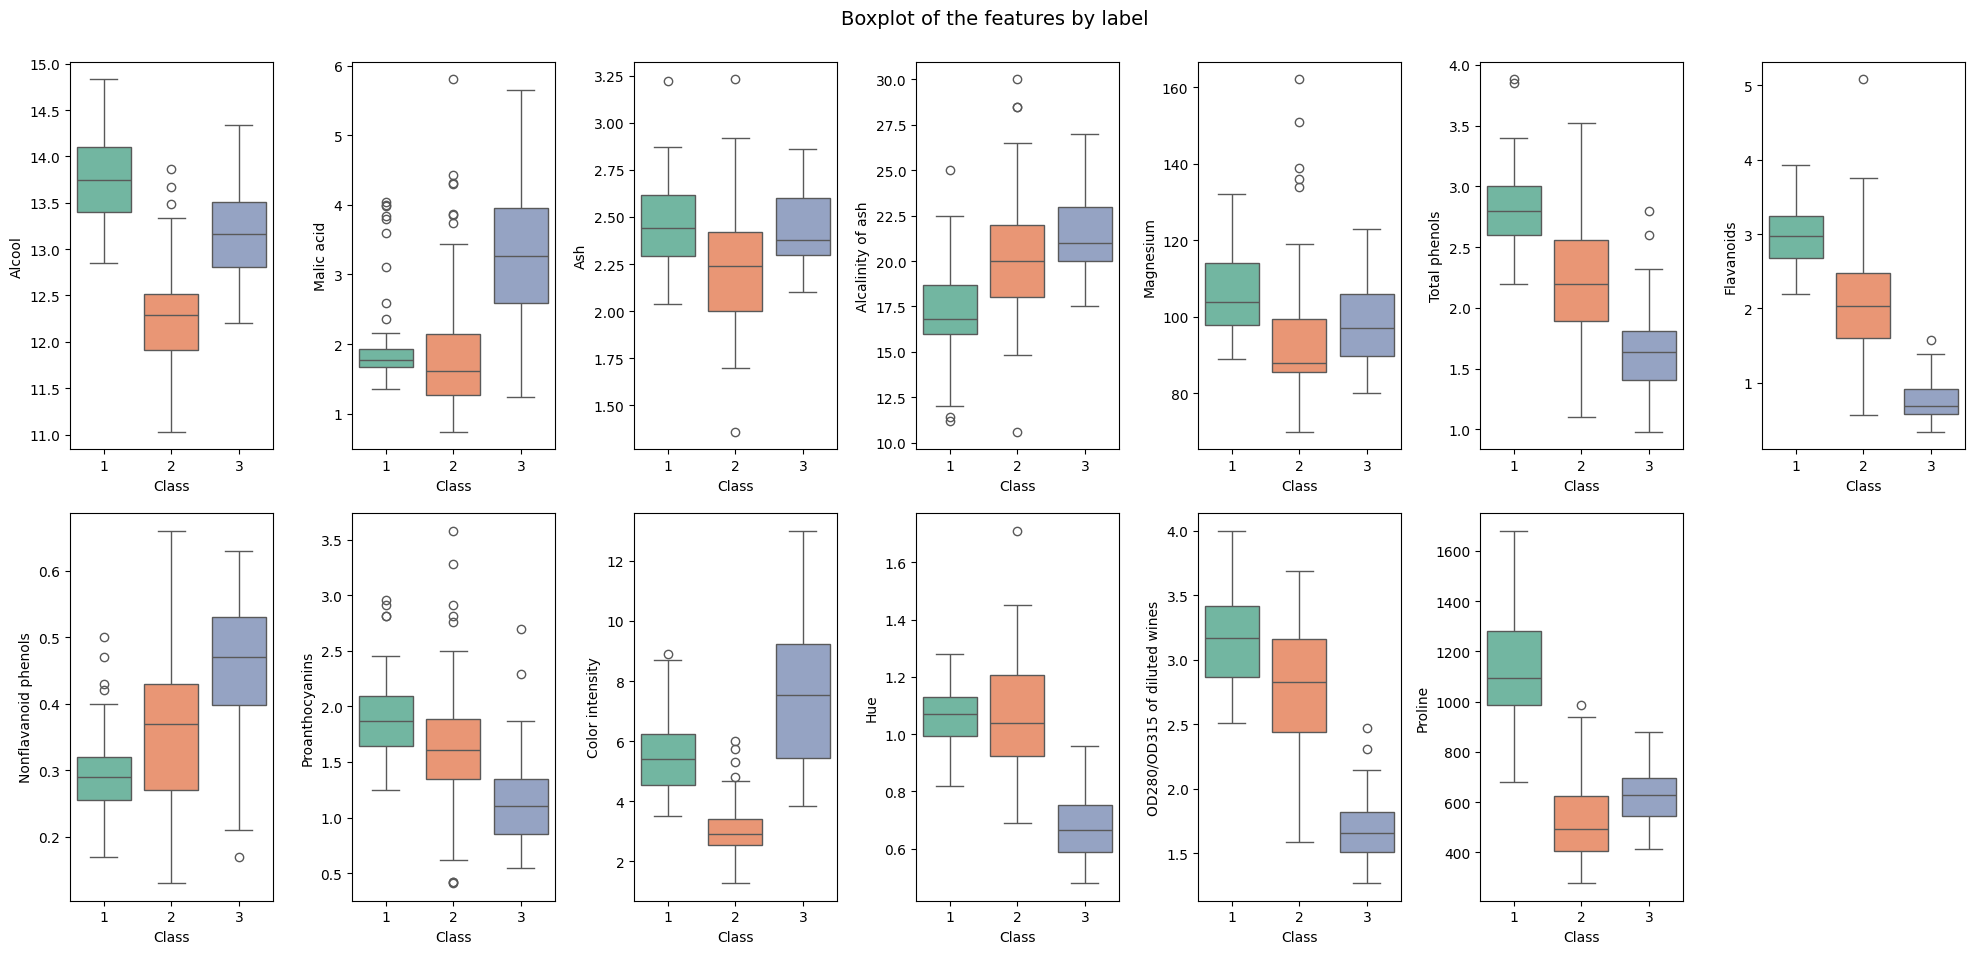

In [4]:
fig, axs = plt.subplots(2, 7, figsize=(20, 10)) # On spécifie le nombre de lignes et de colonnes de notre figure 
axs = axs.flatten() # -> 1D

#----------
# Pour i et chaque nom de colonne sauf class
    # Boxplot avec pour x la Class, et pour y la variable. Utilisez ax=axs[i] pour insérer le plot dans la figure. !
#----------  

for i, columsVar in enumerate(wines.columns[1:]):
    sns.boxplot(
        x=wines['Class'], 
        y=wines[columsVar],
        ax=axs[i],
        palette="Set2"
    )

fig.suptitle('Boxplot of the features by label', fontsize=14)    
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
fig.delaxes(axs[13]) # Supprime le plot vide en bas à droite

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Exercice </b></font> Créez un Pairplot à l'aide de la librairie Seaborn</p>
(4 points)

****

Pour les données avec "peu" de variables, comme dans notre cas, un pairplot peut permettre d'obtenir une excellente vue d'ensemble. Cependant, la génération du pairplot peut prendre un certain temps. Pour éviter de prendre du temps à générer et re-générer le pairplot, vous pouvez commenter votre code une fois que vous avez analysé le graphique.

Note: Vous pouvez désactiver les Warnings s'il y en a. 

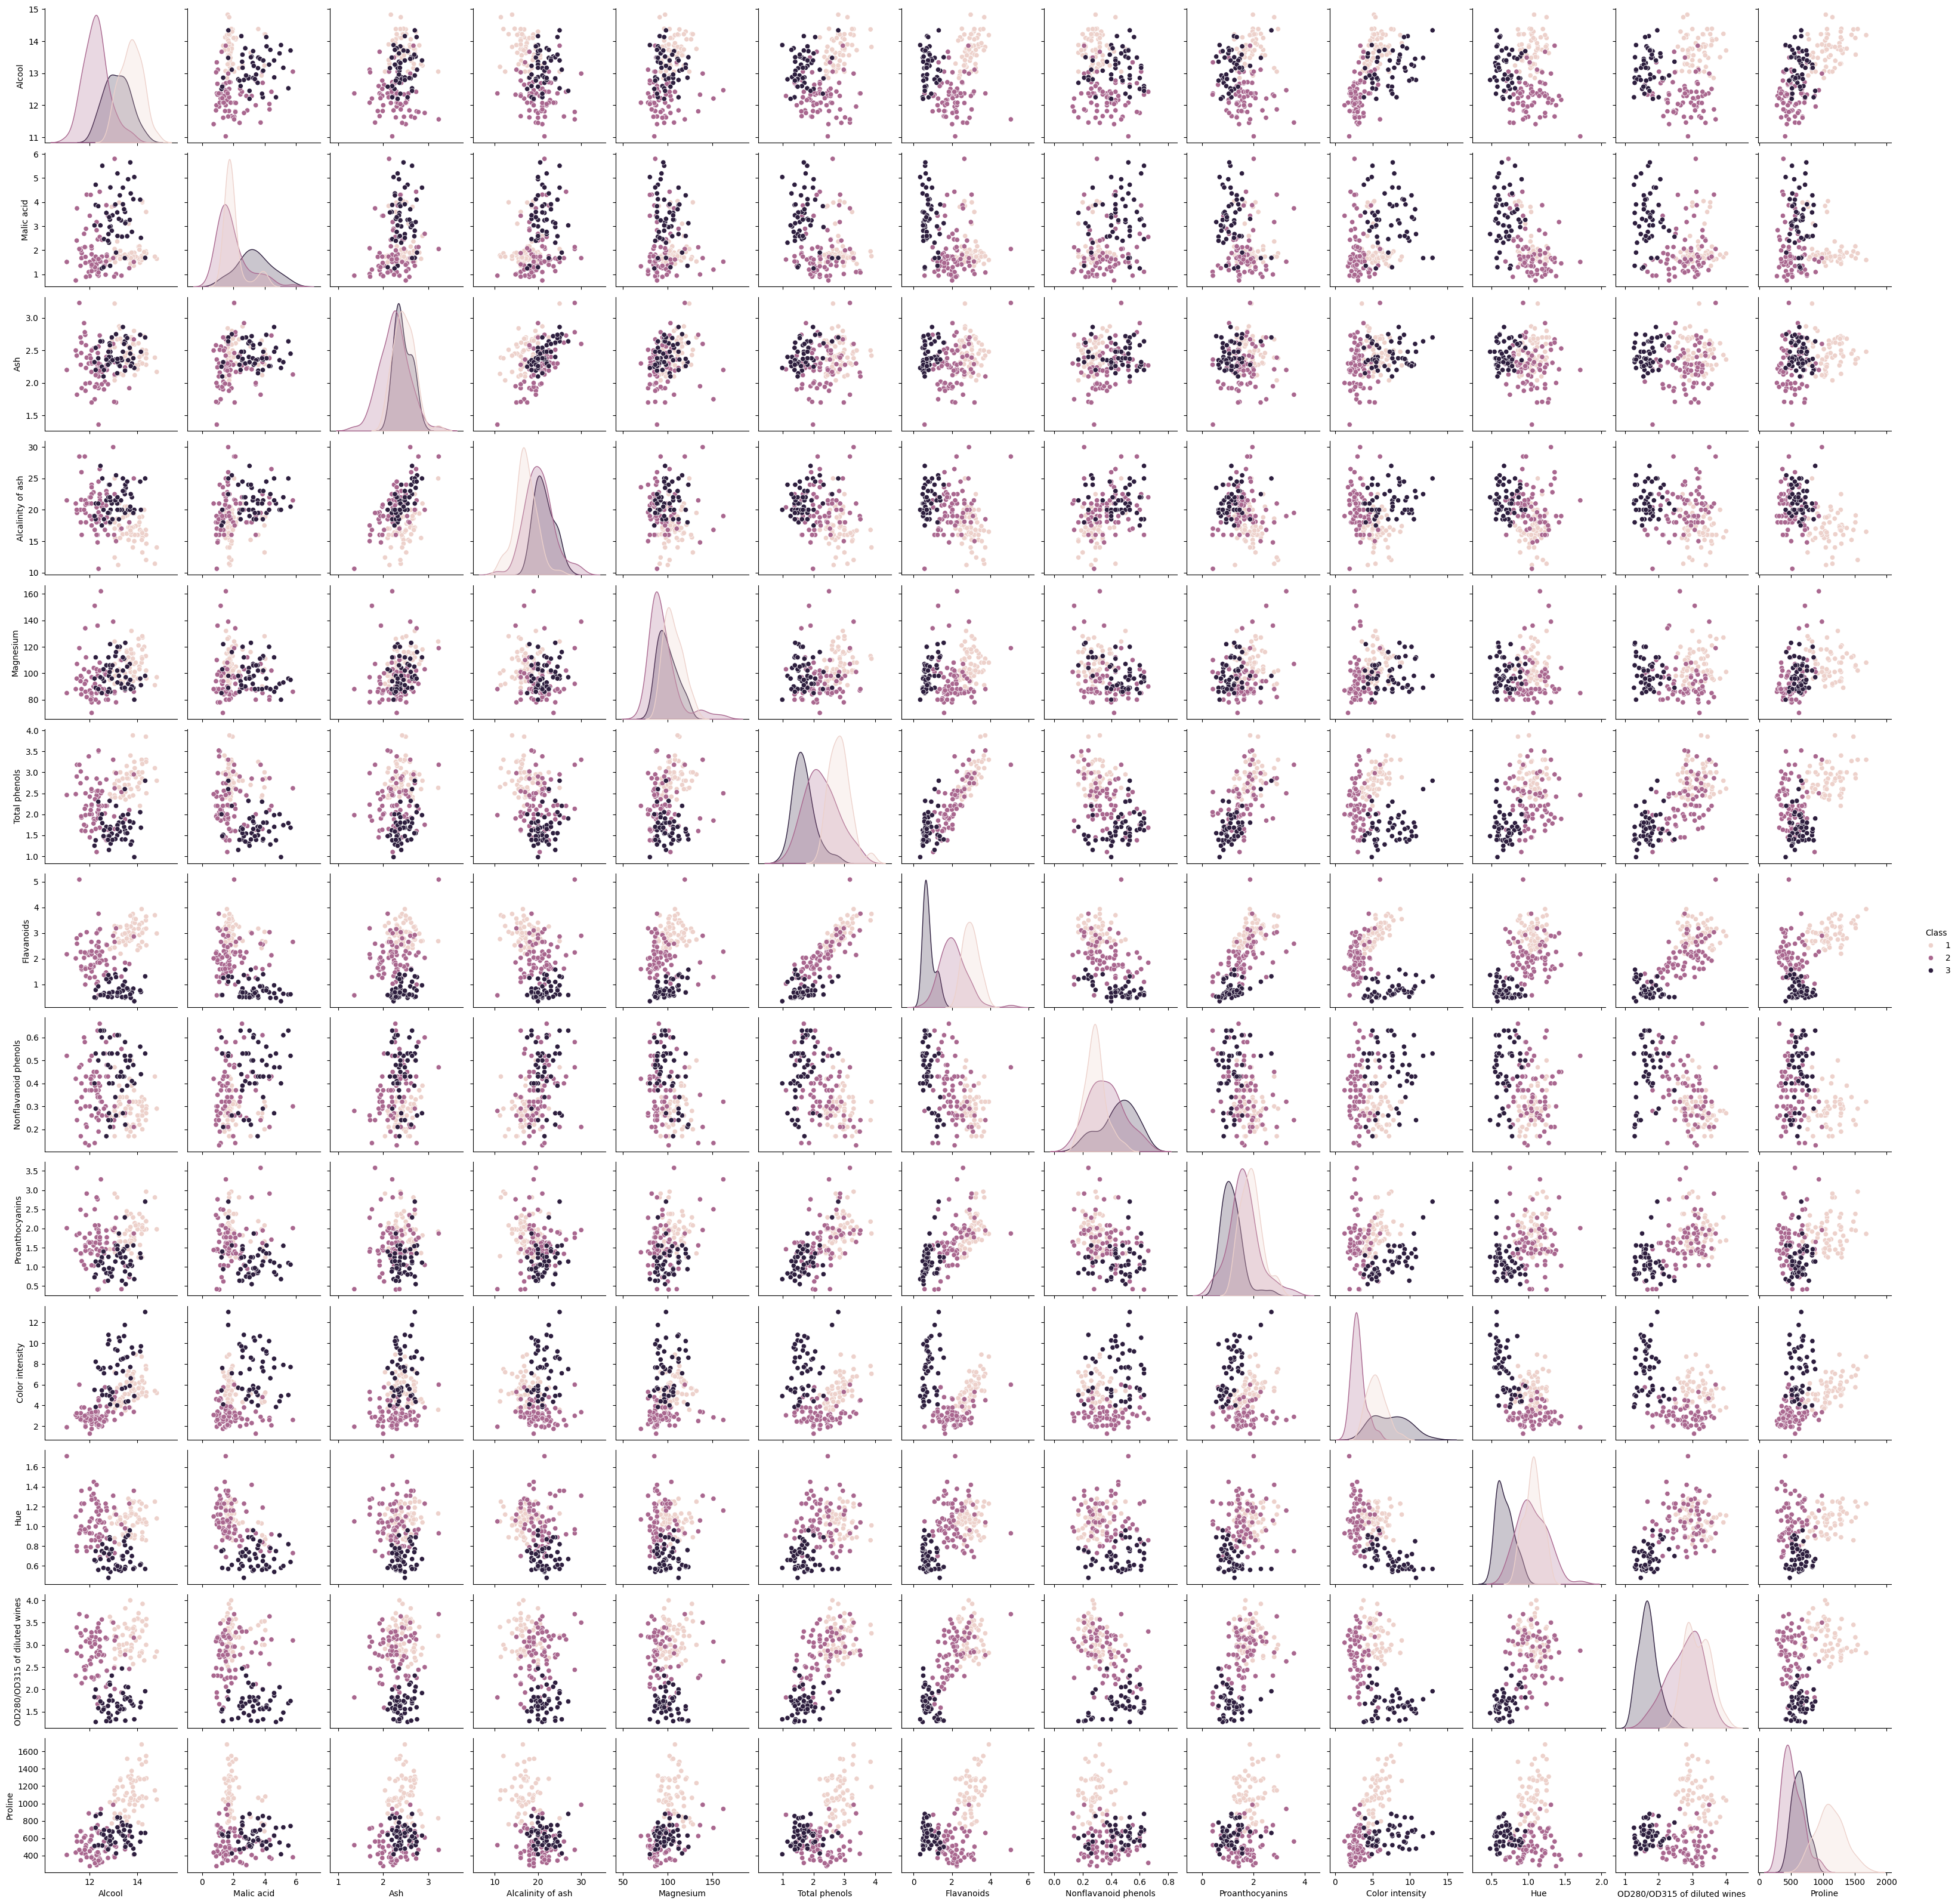

In [5]:
# Pairplot avec Seaborn - Votre code

sns.pairplot(wines, hue='Class')
plt.show()


---

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font>Quels éléments du pairplot permettent de facilement distinguer si les différentes classes sont bien séparées les unes des autres ? </p> (2 points)

*Réponse:* </br>
**Les points colorés dans les graphiques :** si les points de chaque couleur restent dans des zones différentes, alors les classes sont faciles à distinguer.</br>
**Les courbes sur la diagonale :** si les formes des distributions ne se chevauchent presque pas entre les couleurs, cela veut dire que les variables séparent bien les classes.

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> D'après les boxplots, quelles variables permettraient le mieux de distinguer/séparer les trois classes ? Et de distinguer une classe des deux autres ? Donnez 5 variables (en tout) soit pour séparer les 3 classes soit une des deux autres, ainsi que les valeurs approximatives de séparration. </p> (6 points)

<p></p>
<div style="background-color:#EEEEEE;padding:3px">Note: un modèle avec des règles simples peut permettre, par exemple, de distinguer deux classes l'une de l'autre. Par exemple pour distinguer un chat d'un chien sur des valeurs numérique on pourrait avoir les règles suivantes: 

- Si $souplesse < 2$ et $poids > 10$ -> c'est un chien
- Sinon -> c'est un chat. 

Pour pouvoir établir ces règles, il faut donc avoir une vue sur les différentes variables. Ce n'est pas parfait mais le modèle reste simple. Il fonctionnera dans une bonne partie des cas mais on peut toujours tomber sur un Chihuahua souple de moins de 5 kilos par exemple. 

*Réponse:* </br>
**Tableau des règles de classification**

<table>
  <tr>
    <th>Classe</th>
    <th><b>Alcool</b></th>
    <th><b>Flavanoids</b></th>
    <th><b>Color intensity</b></th>
    <th><b>Proline</b></th>
    <th><b>Hue</b></th>
  </tr>

  <!-- Classe 1 -->
  <tr>
    <td><b>1</b></td>
    <td>x ≥ 13.5</td>
    <td>2.5 &lt; x</td>
    <td>4 ≤ x ≤ 6.1</td>
    <td style="background-color:#ffcccc;"><b>x ≥ 900</b></td>
    <td>—</td>
  </tr>

  <!-- Classe 2 -->
  <tr>
    <td><b>2</b></td>
    <td>x ≤ 12.5</td>
    <td>1.5 ≤ x ≤ 2.5</td>
    <td style="background-color:#ffcccc;"><b>x &lt; 4</b></td>
    <td>x ≤ 500</td>
    <td>—</td>
  </tr>

  <!-- Classe 3 -->
  <tr>
    <td><b>3</b></td>
    <td>12.5 &lt; x &lt; 13.5</td>
    <td>x ≤ 1.5</td>
    <td>6.1 &lt; x ≤ 13</td>
    <td>500 &lt; x &lt; 900</td>
    <td style="background-color:#ffcccc;"><b>x ≤ 0.8</b></td>
  </tr>
</table>



Nous avons créé ce tableau à partir de nos propres observations. Ensuite, nous avons demandé à ChatGPT de générer un code permettant d’identifier les classes et les seuils de séparation les plus pertinents pour représenter les éléments. Nous avons utilisé ces résultats uniquement pour comparer nos réponses et vérifier si elles étaient globalement cohérentes et justes.
Cependant, nous n’avons pas utilisé les données produites par ce programme pour construire notre tableau.

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = wines.drop("Class", axis=1)
y = wines["Class"]

# ---------------------------
# 1. Train-test split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)

# ---------------------------
# 2. Importance des variables
# ---------------------------

importances = pd.Series(tree.feature_importances_, index=X.columns)
top5 = importances.sort_values(ascending=False).head(5)

print("🔹 LES 5 VARIABLES QUI DIFFERENCIENT LE PLUS LES CLASSES :")
print(top5)
print()

# ---------------------------
# 3. Extraire les seuils + classes
# ---------------------------

def extract_thresholds_and_classes(clf, feature_names):
    thresholds = []
    tree_ = clf.tree_

    for node in range(tree_.node_count):

        feature_id = tree_.feature[node]
        threshold = tree_.threshold[node]

        # si ce n'est pas une feuille
        if feature_id != -2:

            feature_name = feature_names[feature_id]

            # enfants du noeud (gauche < seuil, droite > seuil)
            left_child = tree_.children_left[node]
            right_child = tree_.children_right[node]

            # classes dominantes dans chaque direction
            left_class = np.argmax(tree_.value[left_child])
            right_class = np.argmax(tree_.value[right_child])

            thresholds.append(
                (feature_name, threshold, left_class + 1, right_class + 1)
            )

    return thresholds


seuils = extract_thresholds_and_classes(tree, X.columns)

print("🔹 SEUILS DE DÉCISION + CLASSES ASSOCIÉES :")
for feat, thr, left_c, right_c in seuils:
    print(f"{feat} < {thr:.3f}  → classe {left_c},   sinon → classe {right_c}")

🔹 LES 5 VARIABLES QUI DIFFERENCIENT LE PLUS LES CLASSES :
Flavanoids         0.444733
Color intensity    0.407669
Hue                0.106862
Alcool             0.040736
Malic acid         0.000000
dtype: float64

🔹 SEUILS DE DÉCISION + CLASSES ASSOCIÉES :
Color intensity < 3.460  → classe 2,   sinon → classe 1
Flavanoids < 2.110  → classe 3,   sinon → classe 1
Hue < 0.970  → classe 3,   sinon → classe 2
Flavanoids < 1.580  → classe 3,   sinon → classe 2
Alcool < 12.785  → classe 2,   sinon → classe 1


<a name="Part112pts"></a>
<div class="alert alert-block alert-info">
<b>Corrections Partie 1.1 - 1.2: </b> Points obtenus: /20
</div>

Remarques de l'assistant: 
- Load data /2
- Q /2
- Plots /8
- Q /2
- Q /6


[Début partie 1](#Part1) --- [Table des matières](#toc)

<p style="background-color:#003c9c;padding:3px"><font size="4"><b></b></font></p>

<a name="Part13"></a>
### 1.3 Création du modèle à base de règles

[Début partie 1](#Part1) --- [Table des matières](#toc)



Suivez la structure du code ci-après pour implémenter un modèle à base de règles. Complétez les parties manquantes et écrivez les fonctions demandées. **Lisez bien les commentaires afin de bien comprendre la logique implémentée**.

# 1.3.1 Définition des règles

Dans cette partie vous allez écrire les règles permettant de distinguer les trois classes à l'aide des variables `Alcool`, `Color intensity` et `Flavanoids`. Utilisez pour cela les valeurs que vous avez trouvées au TP3 ou servez vous des graphiques ci-dessus pour les déterminer. 

Servez-vous de la fonction donnée en exemple (c'est un exemple, pas besoin de recopier exactement la structure. Vous pouvez la changer, mais ça doit retourner 1, 2 ou 3) pour créer les fonctions suivantes (**respectez les noms !**): 

- *class_by_alcool()*: utilise la variable Alcool uniquement. 
- *class_by_flavanoids()*: utilise la variable Flavanoids uniquement.
- *class_by_color_intensity()*: utilise la variable Color intensity uniquement
- *class_by_flav_alcool()*: utilise les variables Flavanoids et Alcool
- *class_by_color_alcool()*: utilise les variables Color intensity et Alcool
- *class_by_color_flav()*: utilise les variables Color intensity et Flavanoids


In [17]:
# Les fonctions suivantes seront appliquées au DataFrame à l'aide de la fonction apply(). 
# Le DataFrame sera donc passé en paramètres et les opérations effectuées sur toutes les observations. 


# ------------------------------------------------------------------
# Définition des règles 
# ------------------------------------------------------------------
'''
def class_by_XXXXXX(df): # ou class_by_XXXXXX_YYYYYY(df):
    """
    Retourne la classe (1, 2 ou 3) selon la variable XXXXXX (et YYYYYY -> en ayant accès à tout le dataframe, on peut
    aussi tester une seconde variable ou plus).
    """
    if(df["XXXXXX"] > 42 and....):
        return 1
    elif(df["YYYYYY"] > 42):
        return 2
    else:
        return 3
'''

    

# Complétez le code selon la donnée ci-dessus en respectant les noms de fonction. 

def class_by_alcool(df):
    if(df["Alcool"] >= 13.5):
        return 1
    elif(df["Alcool"] <= 12.5):
        return 2
    else:
        return 3

def class_by_flavanoids(df):
    if(2.5 < df["Flavanoids"]):
        return 1
    elif(1.5 < df["Flavanoids"] <= 2.5):
        return 2
    else:
        return 3

def class_by_color_intensity(df):
    if(4 <= df["Color intensity"] <= 6.1):
        return 1
    elif(df["Color intensity"] < 4):
        return 2
    else:
        return 3

def class_by_flav_alcool(df):
    if(2.5 < df["Flavanoids"] and df["Alcool"] >= 13.5):
        return 1
    elif(1.5 < df["Flavanoids"] <= 2.5 and df["Alcool"] <= 12.5):
        return 2
    else:
        return 3

def class_by_color_alcool(df):
    if(4 <= df["Color intensity"] <= 6.1 and df["Alcool"] >= 13.5):
        return 1
    elif(df["Color intensity"] < 4 and df["Alcool"] <= 12.5):
        return 2
    else:
        return 3

def class_by_color_flav(df):
    if(4 <= df["Color intensity"] <= 6.1 and 2.5 < df["Flavanoids"] <= 4):
        return 1
    elif(df["Color intensity"] < 4 and 1.5 < df["Flavanoids"] <= 2.5):
        return 2
    else:
        return 3


#### 1.3.2 Prédictions

Pour chacune des règles créées ci-dessus, ajoutez une colonne dans df, une copie du DataFrame wines. Utilisez des noms parlants comme "pred_alcool" ou "pred_alcool_flav" afin que l'on comprenne bien de quelle prédiction il s'agit. Un exemple de l'utilisation de la fonction apply() est donné en commentaire. 


In [19]:
# ------------------------------------------------------------------
# Creation de la / des colonnes de prédiction 
# ------------------------------------------------------------------

# Copie du DataFrame pour ne pas modifier l'original accidentellement. 
df = wines.copy()

# Créez une nouvelle colonne qui contient le résultat de la fonction class_by_YYYYYY
# Faites le pour chaque fonction créées ci-dessus.

# Exemple: df["pred_NNN"] = df.apply(class_by_YYYYYY, axis=1)

df["pred_alcool"] = df.apply(class_by_alcool, axis=1)
df["pred_flavanoids"] = df.apply(class_by_flavanoids, axis=1)
df["pred_color_intensity"] = df.apply(class_by_color_intensity, axis=1)

df["pred_flav_alcool"] = df.apply(class_by_flav_alcool, axis=1)
df["pred_color_alcool"] = df.apply(class_by_color_alcool, axis=1)
df["pred_color_flav"] = df.apply(class_by_color_flav, axis=1)

#df

<a name="Part14"></a>
### 1.4 Matrice de confusion

[Début partie 1](#Part1) --- [Table des matières](#toc)




Affichez les scores (Accuracy) et matrices de confusion pour chaque règles. Pour cela, on utilise les fonctions **accuracy_score()**, **confusion_matrix()** et **ConfusionMatrixDisplay()** fournies par ScikitLearn et importée en amont de ce Notebook. 

Inspirez-vous du code partiellement donné en exemple ci-dessous. Vos résultats doivent cependant être présentés de manière à ce qu'on puisse savoir à quelle règle correspond quelle accuracy /  matrice de confusion. 

--- Modèle : Alcool ---
Accuracy : 69.66%


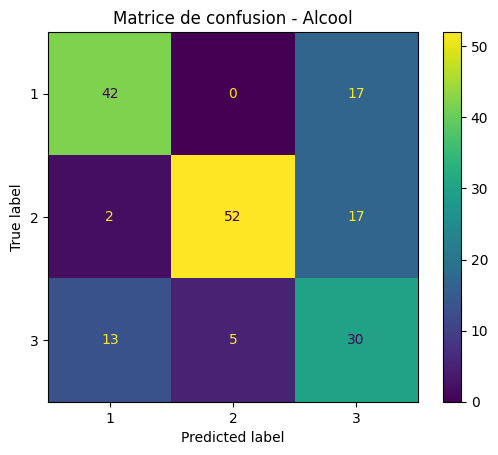



--- Modèle : Flavanoids ---
Accuracy : 79.21%


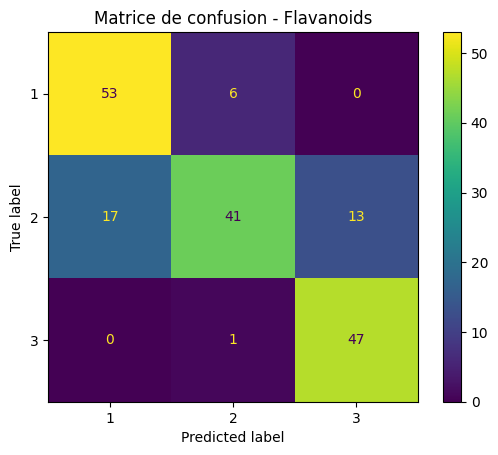



--- Modèle : Color intensity ---
Accuracy : 70.22%


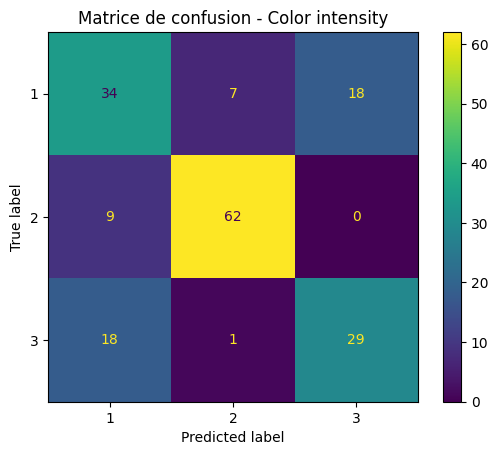



--- Modèle : Flav + Alcool ---
Accuracy : 67.98%


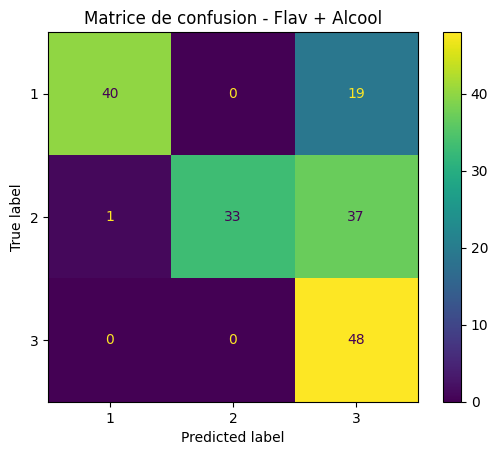



--- Modèle : Color + Alcool ---
Accuracy : 62.92%


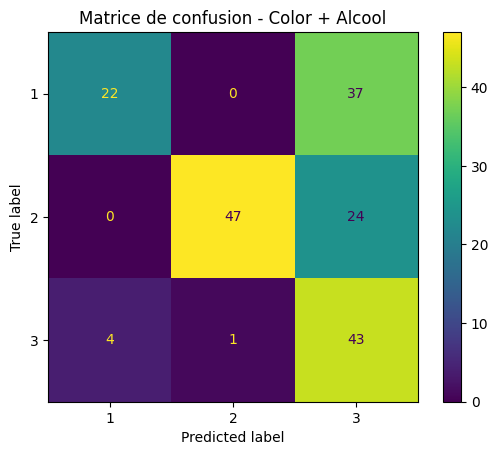



--- Modèle : Color + Flav ---
Accuracy : 65.17%


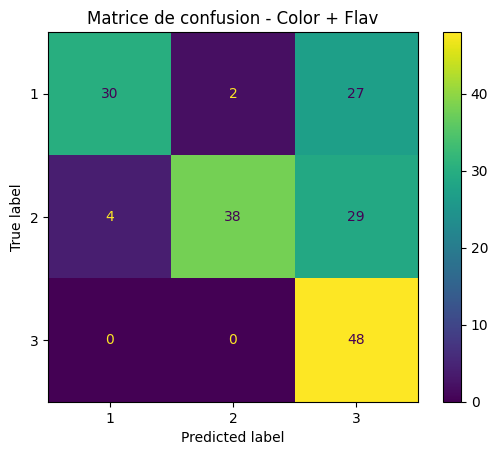

In [20]:
# ------------------------------------------------------------------
# Pour chaque modèle (6x), affichez le score (Accuracy) et la matrice de confusion (code ci-dessous)
# ------------------------------------------------------------------

# Vous pouvez écrire une boucle pour afficher le score et la matrice à la suite ou dans des cellules séparées. 
# Libre à vous de choisir la solution qui vous plait le plus !

'''
score = accuracy_score(...)
print(f"Accuracy: {score}")

cm = confusion_matrix(...)
disp = ConfusionMatrixDisplay(...)
disp.plot()
plt.show()
'''



models = [
    ("Alcool", "pred_alcool"),
    ("Flavanoids", "pred_flavanoids"),
    ("Color intensity", "pred_color_intensity"),
    ("Flav + Alcool", "pred_flav_alcool"),
    ("Color + Alcool", "pred_color_alcool"),
    ("Color + Flav", "pred_color_flav")
]

for model_name, col in models:
    print(f"--- Modèle : {model_name} ---")
    
    y_true = df["Class"]
    y_pred = df[col]
    
    # Accuracy
    acc = accuracy_score(y_true, y_pred)*100
    print(f"Accuracy : {acc:.2f}%")
    
    # Matrice de confusion + affichage
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(f"Matrice de confusion - {model_name}")
    plt.show()
    print("\n")
    

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font>Laquelle de vos règles donne le meilleur résultat ? Y a-t-il une classe plus difficile à prédir qu'une autre ?</p>

*Réponses:* <br/>

**Analyse des résultats**

Parmi toutes les règles testées, celle qui donne les meilleurs résultats est la règle basée sur **les Flavanoids**, avec une accuracy d’environ **79 %**. Elle est suivie par la règle utilisant **l’intensité de couleur** (≈ 70 %) puis par la règle **Alcool** (≈ 69 %). Cela montre que, dans ce cas, les Flavanoids sont la variable qui permet le mieux de séparer les différents types de vins.

En observant les matrices de confusion, on remarque aussi que **la classe 2 est la plus difficile à prédire**. Elle est régulièrement confondue avec les classes **1** et **3**, peu importe la règle utilisée. Les cases correspondant à « vraie classe = 2 » montrent souvent des valeurs importantes dans les colonnes 1 et 3, ce qui signifie que le modèle attribue souvent une mauvaise classe aux vins appartenant réellement à la classe 2.

Au contraire, les classes **1** et **3** sont généralement mieux reconnues : les bonnes prédictions sont plus nombreuses dans les diagonales correspondantes, et les erreurs sont moins fréquentes.

En résumé, la règle Flavanoids est la plus performante, et la classe 2 reste la plus difficile à identifier correctement, car elle est souvent confondue avec les deux autres classes.


<a name="Part134pts"></a>
<div class="alert alert-block alert-info">
<b>Corrections Partie 1.3 - 1.4: </b> Points obtenus: /16
</div>

Remarques de l'assistant: 
- Règles (6) et prédictions (4 pts): /10
- Matrices de confusion: /4
- Question: /2


[Début partie 1](#Part1) --- [Table des matières](#toc)

<p style="background-color:#003c9c;padding:3px"><font size="4"><b></b></font></p>

---

<p style="background-color:#7ba3e3;padding:10px"><font size="6"><b></b></font></p>

---

<a name="Part2"></a>

## Partie 2 - L'algorithme des k plus proches voisins (k-NN) 

[Table des matières](#toc)

Dans cet exercice, nous allons utiliser KNN pour traiter le problème de classification des vins.  


[- 2.1 Implémentation](#Part21)    ----    [12 points](#Part21pts)

[- 2.2 Validation hold-out](#Part22)    ----    [10 points](#Part22pts)

[- 2.3 N-Folds Cross Validation](#Part23)    ----    [10 points](#Part23pts)

[- 2.4 Conclusion](#Part24)    ----    [8 points](#Part24pts)


<a name="Part21"></a>
### 2.1 Implémentation et préparration des données
[Table des matières](#toc)

Le code suivant est tiré du cours. Complétez les [docstrings](https://www.datacamp.com/tutorial/docstrings-python#multi-line-docstring-multi) de manière à indiquer ce que fait la fonction, quels sont les paramètres ainsi que la valeur de retour. Ajoutez en plus des commentaires sur les parties complexes afin de montrer que vous avez compris l'implémentation de KNN. 


In [27]:
# Code du cours - TODO Complétez les docstrings 


def train_test_split(dataset, split=0.60):
    """
    Sépare un ensemble de données en deux sous-ensembles : entraînement et test.

    Cette fonction sélectionne aléatoirement une partie de l'ensemble de données
    (par défaut 60 %) pour constituer l'ensemble d'entraînement, et conserve le reste
    pour l'ensemble de test.

    Paramètres
    ----------
    dataset : list ou iterable
        L'ensemble de données complet à diviser.
    split : float, optionnel
        Proportion des données à inclure dans l'ensemble d'entraînement.
        Doit être comprise entre 0 et 1. La valeur par défaut est 0.60.

    Retours
    -------
    tuple
        Un tuple (train, test) où :
        - train (list) : sous-ensemble aléatoire contenant split * len(dataset) éléments
        - test (list) : les éléments restants de l'ensemble de données
    """
    train = list()
    train_size = split * len(dataset)
    test = list(dataset)
    while len(train) < train_size:
        index = randrange(len(test))
        train.append(test.pop(index))
    return train, test


def euclidean_distance(row1, row2):
    """
    Calcule la distance euclidienne entre deux lignes d’un jeu de données.

    La fonction ignore la première colonne (souvent utilisée comme étiquette de classe)
    et calcule la distance en utilisant uniquement les attributs numériques restants.

    Paramètres
    ----------
    row1 : (list)
        Première ligne de données.
    row2 : (list)
        Deuxième ligne de données.

    Retourne
    -------
    float
        La distance euclidienne entre les deux lignes.
    """

    distance = 0.0
    for i in range(1, len(row1)): # All columns except the first one (Class) - Wrong in course's PDF
        distance += (row1[i] - row2[i])**2
    
    return sqrt(distance)


def get_neighbors(train, test_row, num_neighbors):
    """
    Sélectionne les k plus proches voisins d’une ligne de test dans un ensemble d’entraînement.

    Pour chaque ligne de l’ensemble d’entraînement, la fonction calcule la distance
    euclidienne par rapport à la ligne test. Les lignes sont ensuite triées selon
    cette distance, et les k premières (les plus proches) sont retournées.

    Paramètres
    ----------
    train : list[list[float]]
        Ensemble d’entraînement contenant les lignes de données.
    test_row : list[float]
        Ligne de test pour laquelle on souhaite trouver les voisins.
    num_neighbors : int
        Nombre de voisins les plus proches à retourner.

    Retourne
    -------
    list[list[float]]
        Les k lignes de l’ensemble d’entraînement les plus proches de test_row.
    """
    distances = list()
    for train_row in train:
        dist = euclidean_distance(test_row, train_row)
        distances.append((train_row, dist))
    distances.sort(key=lambda tup: tup[1])
    neighbors = list()
    for i in range(num_neighbors):
        neighbors.append(distances[i][0])
    return neighbors


def predict_classification(train: pd.DataFrame, test_row, num_neighbors):
    """
    Prédit la classe d’une ligne de test à l’aide de l’algorithme des k plus proches voisins (k-NN).

    La fonction récupère d’abord les k voisins les plus proches de la ligne test.
    Ensuite, elle extrait leur étiquette (première colonne) et sélectionne
    la classe la plus fréquente parmi ces voisins.

    Paramètres
    ----------
    train : pandas.DataFrame
        Ensemble d’entraînement contenant les observations étiquetées.
    test_row : list[float] ou pandas.Series
        Ligne de test pour laquelle on veut prédire la classe.
    num_neighbors : int
        Nombre de voisins à considérer pour la prédiction.

    Retourne
    -------
    any
        La classe prédite, correspondant à la valeur la plus fréquente
        parmi les voisins sélectionnés.
    """
    neighbors = get_neighbors(train, test_row, num_neighbors)
    output_values = [row[0] for row in neighbors]
    #print(f"Output values classification: {output_values}")
    prediction = max(set(output_values), key=output_values.count)
    return prediction


def accuracy_metric(actual: list[float], predicted: list[float]):
    """
    Calcule le taux de précision (accuracy) entre les valeurs réelles
    et les valeurs prédites.

    La fonction compare chaque prédiction avec la valeur réelle
    correspondante et compte le nombre de correspondances exactes.
    Le pourcentage de prédictions correctes est ensuite retourné.

    Paramètres
    ----------
    actual : list[float]
        Liste des valeurs réelles (étiquettes correctes).
    predicted : list[float]
        Liste des valeurs prédites par le modèle.

    Retourne
    -------
    float
        Le pourcentage de prédictions correctes (accuracy), exprimé en pourcentage.
    """
    correct = 0
    for i in range(len(actual)):
        if actual[i] == predicted[i]:
            correct += 1
    return correct / float(len(actual)) * 100.0


def cross_validation_split(dataset, n_folds):
    """
    Divise un jeu de données en n sous-ensembles (folds) pour la validation croisée.

    La fonction crée une copie du jeu de données, puis sélectionne aléatoirement
    des observations pour remplir chaque fold. Chaque sous-ensemble contient
    approximativement la même taille, et aucun élément n'est dupliqué.

    Paramètres
    ----------
    dataset : list
        Jeu de données complet à diviser.
    n_folds : int
        Nombre de sous-ensembles à créer pour la validation croisée.

    Retourne
    -------
    list[list]
        Une liste contenant n_folds sous-ensembles, chacun étant une partie du dataset.
    """
    dataset_split = list()
    dataset_copy = list(dataset)
    fold_size = int(len(dataset) / n_folds)
    for _ in range(n_folds):
        fold = list()
        while len(fold) < fold_size:
            index = randrange(len(dataset_copy))
            fold.append(dataset_copy.pop(index))
        dataset_split.append(fold)
    return dataset_split


Création de deux datasets: 
- un avec les données brutes
- un avec les données normalisées

**Lisez sans modifier le code ci-dessous pour en comprendre le sens et répondez aux questions.**

In [22]:
# Préparation des datasets - rien à modifier

#=====================================================================
# Préparation des données brutes 
#=====================================================================

# Conversion en liste de listes au lieu de DataFrame
data = wines.values.tolist()

#=====================================================================
# Préparation des données normalisées
#=====================================================================


# Différents moyens de standardiser les données mise à disposition par Scikit-learn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Nous allons utiliser le StandardScaler, qui va normaliser les données avec une moyenne de 0 et un écart-type de 1
scaler = StandardScaler()
scaler_string = "StandardScaler" # pour l'affichage dans le titre des plots si nécessaire


# Créer une copie et prendre une liste des colonnes des données indépendantes (entrées)
df_normalized = wines.copy()
cols = wines.columns[wines.columns != 'Class']

# Remplacer les colonnes des données par les données transformées
df_normalized[cols] = scaler.fit_transform(df_normalized[cols])

# conversion en liste de listes pour k-NN
data_normalized = df_normalized.values.tolist()

# K's à tester
Ks = [1, 2, 3, 5, 7, 10]

In [12]:
df_normalized

,Class,Alcool,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,1,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,1,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,3,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,3,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,3,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


**Ci-dessous, affichez les boxplots des données normalisées, comme pour les données du [point 1.2](#Part12).**

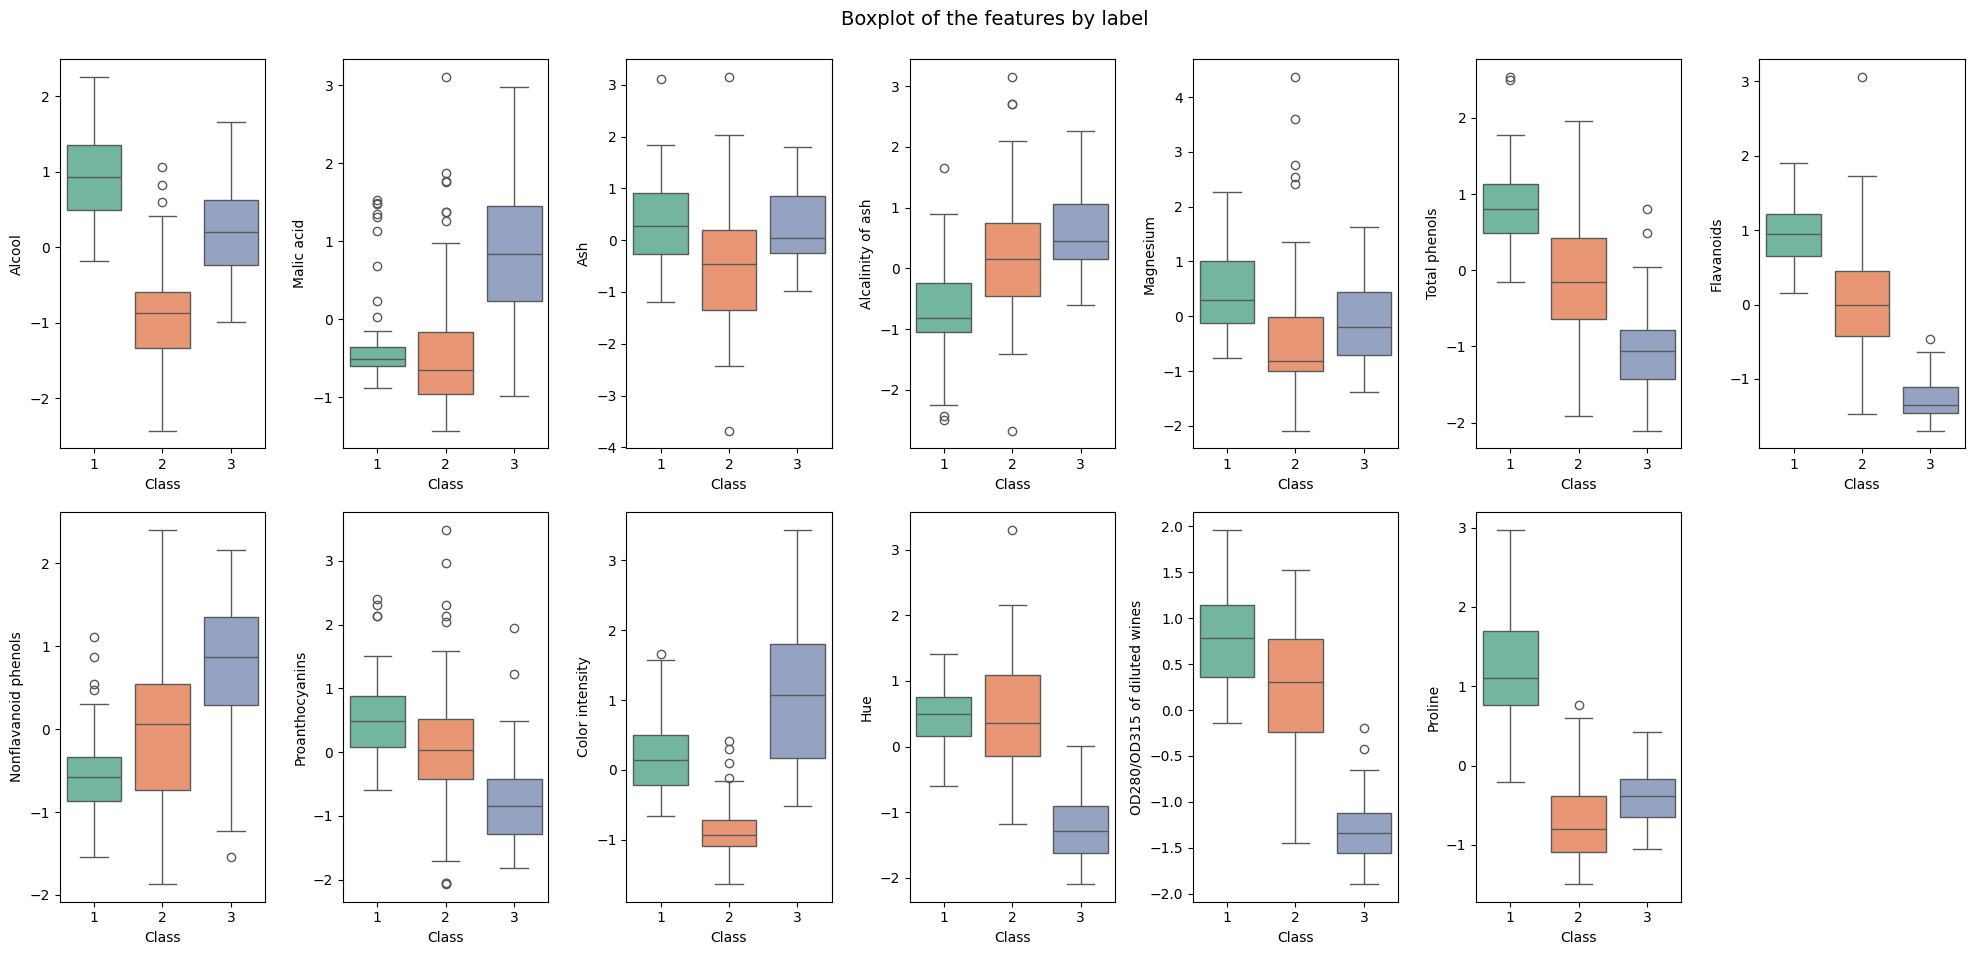

In [23]:
# Votre code

fig, axs = plt.subplots(2, 7, figsize=(20, 10))
axs = axs.flatten()

for i, columsVar in enumerate(df_normalized.columns[1:]):
    sns.boxplot(
        x=df_normalized['Class'], 
        y=df_normalized[columsVar],
        ax=axs[i],
        palette="Set2"
    )

fig.suptitle('Boxplot of the features by label', fontsize=14)    
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
fig.delaxes(axs[13])

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font>Quelle est la différence entre un commentaire et une docstring ? </p> (1 point)

*Réponse:* <br/>
En Python, un commentaire sert uniquement à expliquer le code pour le développeur, tandis qu’une docstring sert à documenter officiellement une fonction ou un module, afin qu’un utilisateur puisse comprendre son rôle, ses paramètres et ce qu’elle retourne.

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> Qu'est-ce que la normalisation des données ? </p> (1 point)

Décrivez le concept en quelques mots. Attention, les termes "Normalisation" et "Standardisation" sout souvents mélangés mais le concept général reste le même !


*Réponse:*
<br/>
La normalisation des données consiste à ramener toutes les variables sur une même échelle; par exemple, dans notre dataset, "Hue" varie autour de 1 alors que "Proline" peut dépasser 1 000, ce qui ferait totalement dominer Proline dans les calculs de distance (euclidean distance). Normaliser permet donc d’équilibrer ces différences pour que chaque variable contribue de manière équitable au modèle.

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> Quelles sont les différences entre les StandardScaler, MinMaxScaler et RobustScaler ?</p> (3 points)

Note: Aidez-vous de [la doc](https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling) ou d'autres ressources pour répondre. 

*Réponse:* <br/>
Les trois méthodes servent à mettre les données à la même échelle, mais chacune le fait différemment.<br/>
Le StandardScaler centre les données en retirant la moyenne et en divisant par l’écart-type : il fonctionne très bien quand il n’y a pas d’outliers, mais il est sensible aux valeurs extrêmes.<br/>
Le MinMaxScaler transforme toutes les valeurs pour qu’elles se retrouvent dans un intervalle fixe (souvent entre 0 et 1). Cette méthode est simple, mais elle peut être fortement déstabilisée par un outlier, car une seule valeur très grande ou très petite étire toute l’échelle.<br/>
Le RobustScaler, lui, utilise la médiane et l’intervalle interquartile, ce qui le rend beaucoup moins sensible aux valeurs extrêmes. C’est le scaler idéal lorsque les données contiennent des outliers.<br/>

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> Quelles différences observez-vous entre les boxplots des données originales du point 1.2 par rapport aux boxplots avec les données normalisées ?</p>(1 points)

Voir [point 1.2](#Part12). 

*Réponse:*<br/> Les boxplots des données originales montrent des échelles très différentes selon les variables : certaines ont des valeurs très grandes, d’autres très petites, ce qui rend la comparaison difficile.
Après normalisation, toutes les variables sont ramenées à la même échelle. Les boxplots deviennent donc beaucoup plus comparables : on voit mieux les différences entre les classes, sans être influencé par les unités ou l’amplitude d’origine.

<a name="Part21pts"></a>
<div class="alert alert-block alert-info">
<b>Corrections Partie 2.1: </b> Points obtenus: /12
</div>

Remarques de l'assistant: 

- docstrings: /6
- Questions: /6


[Début partie 2](#Part2) --- [Table des matières](#toc)

<p style="background-color:#003c9c;padding:3px"><font size="4"><b></b></font></p>



<a name="Part22"></a>
### 2.2 Validation hold-out
[Table des matières](#toc)

Nous allons ici utiliser la méthode "Validation Hold-Out" avec k-NN sur nos données. 

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Exercice </b></font> Complétez le code ci-dessous en suivant les indications en commentaire. Respectez le nombre de lignes indiqué.</p> (6 points)



Vous allez afficher pour chaque dataset les performances pour chaque K (N fois). Utilisez en premier le dataset "***data***" puis une fois votre code fonctionnel, ajoutez un niveau de boucle pour faire deux graphiques et effectuez la même opération en plus pour le dataset avec les données normalisées: "***data_normalized***". 


*Supprimez le print() dans la boucle qui est là pour que le code ne crash pas avant que vous l'ayez complété.* 

Aide: 
- Vous devez modifier différentes variables, comme par exemple ajouter une dimention à la variable qui contient les résultats. Pour cela on vous conseille de créer deux dictionnaires (comme c'est déjà fait), un pour les données originales et un pour les données normalisées puis de créer une liste "results" contenant vos deux dictionnaires de résultats. N'oubliez pas de modifier le titre des graphiques pour plus de clareté (indiquez quel données sont utilisées). 
- Si vous voulez boucler sur les éléments d'une liste (contenant par exemple deux datasets) vous pouvez utiliser la fonction *enumerate()* qui retourne chaque élément en plus d'un indice (qu'on appelera j ou l par exemple)
- Pour adapter le titre de vos graphiques, vous pouvez simplement créer une liste avec deux titres et utiliser votre variable de boucle pour choisir le bon titre





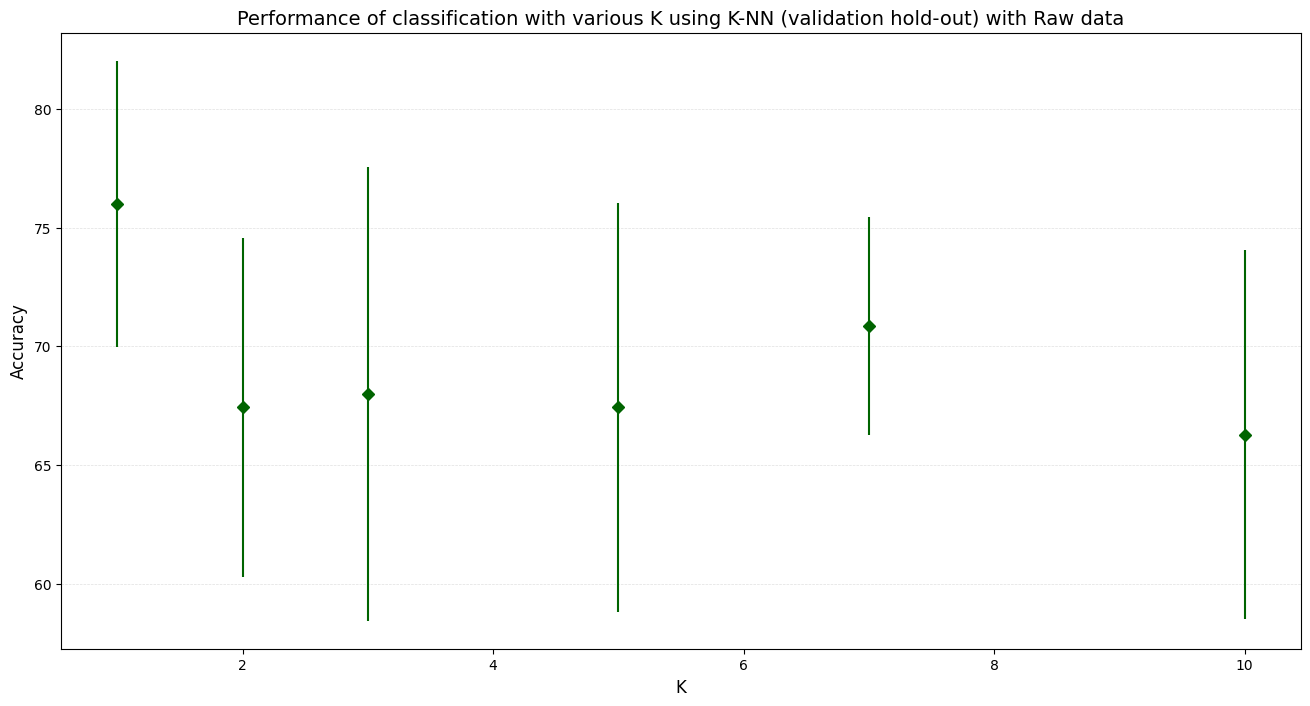

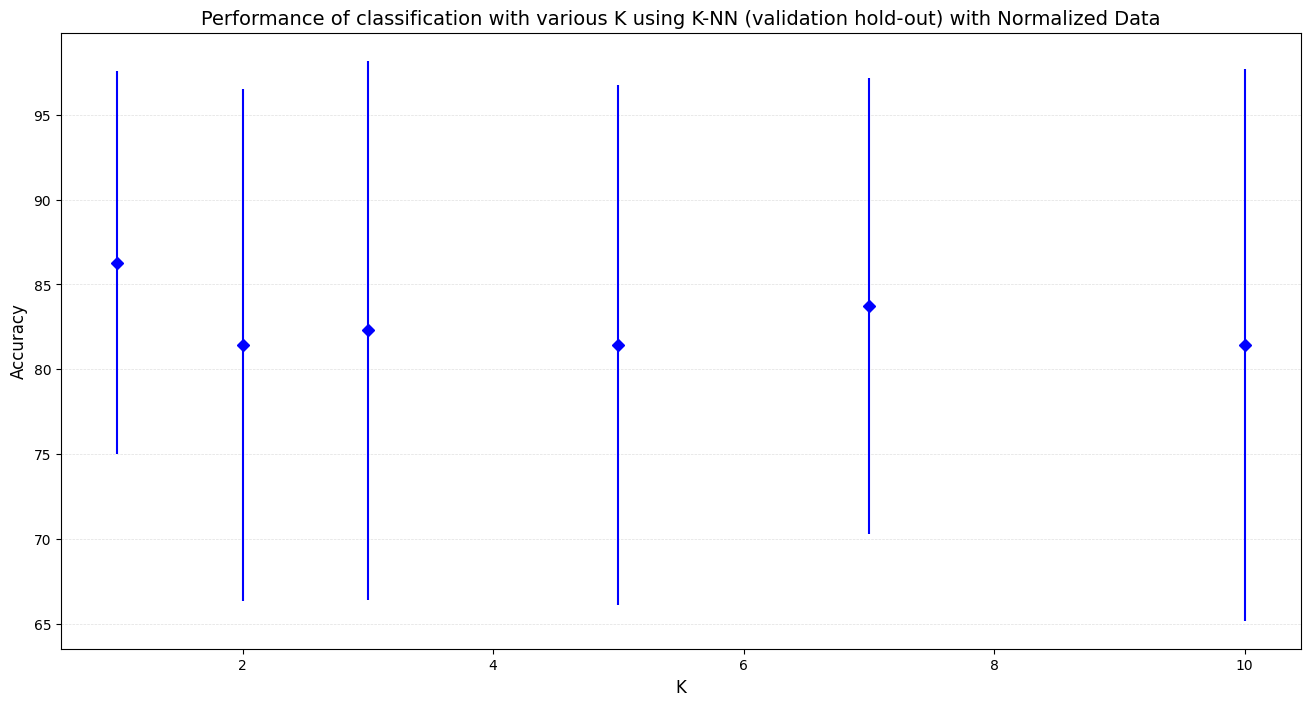

In [28]:
# Complétez le code ci-dessous. Attention, les données sont dans "data"/"data_normalized" et non dans "wines":


# Nous voulons 10 répétitions avec la méthode validation hold-out
N_REPETITIONS = 10

# Nous allons stocker les résultats dans un dictionnaire, avec pour chaque k une liste d'accuracy. 
results = defaultdict(list)

def creat_graphe_kNN_performance(dataSet, nameGraphe, colorGraphe) :
    # Pour chaque validation hold-out (test et train set différents) on test chaque k
    for i in range(N_REPETITIONS):
        for k in Ks:
            #print(f"----- N = {i} - k = {k} -----")  # Vous pouvez supprimer cette ligne une fois votre code fonctionnel
                                                     # Pour que le code tourne, la boucle ne doit pas être vide ;-)  
            
            # Faire le train-test split avec split = 0.8. 
            # La fonction retourne deux éléments, utilisez le unpacking pour les extraire (train, test = fct())
            # - complétez - 1 ligne
            train, test = train_test_split(dataSet, split=0.8)
    
            
            # Obtenir les prédictions à l'aide de la fonction predict_classification()
            # Aide: utilisez la compréhension de liste:  prédictions = [prediction(...) for ... in ...] 
            #                                                                           pour chaque observation de test
            #       Vous devez générer une liste de prédictions (1, 2 ou 3), que vous comparerez en dessous avec 
            #         les valeurs justes pour obtenir l'accuracy.
            
            # - complétez - 1 ligne
            predictions = [predict_classification(train, test_row, k) for test_row in test]
    
            
            # Joindre à results[k] la liste des accuracies (obtenu avec la fonction accuracy_metric() ci dessus)
            # Aide: utilisez la méthode append() pour joindre l'accuracy aux résultats
            # Aide: utilisez la méthode accuracy_metric() pour obtenir l'accuracy
            # Aide: Vous avez une liste de prédictions et un dataframe original (test)
            #       utilisez la compréhension de liste pour créer la liste des données originales:
            #         [colone "Class" pour chaque ligne des tests]
            
            # - complétez - 1 ligne (si vous y arrivez, sinon plus)
            results[k].append(accuracy_metric([row[0] for row in test], predictions))
        

    # Une fois le code fonctionnel, vous devrez bouger le graphique à l'intérieur de la boucle 
    # N'oubliez pas de changer le titre selon les données utilisées !
    
    _, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    means = [np.mean(v) for v in results.values()]
    stds = [np.std(v) for v in results.values()]
    
    ax.errorbar(results.keys(), means, stds, linestyle='None', marker='D', color=colorGraphe)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xlabel('K', fontsize=12)
    ax.set_title(nameGraphe, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.4, lw=0.5)


creat_graphe_kNN_performance(data, 'Performance of classification with various K using K-NN (validation hold-out) with Raw data', 'darkgreen')
creat_graphe_kNN_performance(data_normalized, 'Performance of classification with various K using K-NN (validation hold-out) with Normalized Data', 'blue')

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> Pour quelle valeur(s) de k le modèle est-il le plus efficace avec les données originales ? Et avec les données normalisées ? Une fois les données normalisées, quelle différence observe-t-on ? Justifiez.</p>
(2 points)

Note: Les résultats peuvent varier d'une exécution à l'autre. Indiquez la tendance générale que vous observez.



*Réponse:*


## Analyse des résultats selon la valeur de k

Les résultats peuvent changer légèrement à chaque exécution, car la séparation entre les données d’entraînement et de test se fait de manière aléatoire. Malgré cela, une tendance générale se dégage clairement.

### Données originales

Avec les données non normalisées, le modèle obtient ses meilleures performances pour les petites valeurs de **k**, en particulier pour **k = 1** et parfois pour **k = 3**. Pour ces valeurs, l’accuracy est généralement la plus élevée, même si elle reste relativement limitée. Cela s’explique par le fait que les variables du jeu de données n’ont pas la même échelle, ce qui influence fortement la distance utilisée par l’algorithme k-NN.

### Données normalisées

Après normalisation, les performances du modèle deviennent nettement meilleures. Les valeurs de **k** qui donnent les meilleurs résultats sont souvent **k = 1**, **k = 3** ou **k = 5**. Dans tous les cas, l’accuracy est plus élevée que celle obtenue avec les données originales, et les variations entre les répétitions sont moins importantes.

### Différence observée après normalisation

La normalisation met toutes les variables sur la même échelle. Cela évite qu’une colonne ayant de grandes valeurs numériques influence trop le calcul des distances. Grâce à cette mise à l’échelle, le calcul des distances devient plus équilibré, ce qui permet au modèle k-NN de mieux distinguer les observations proches ou éloignées. C’est pour cette raison que les résultats sont plus stables et plus précis avec les données normalisées.

En résumé, même si les valeurs exactes changent d’une exécution à l’autre, le modèle est toujours plus efficace après normalisation, et les meilleures performances sont obtenues pour des valeurs de k relativement petites.



<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> Pourquoi les résultats varient d'une exécution à une autre ? Décrivez le fonctionnement de ce que vous venez de faire (point 2.1) en quelques phrases.</p> (2 points)

*Réponse*


Les résultats changent d’une exécution à l’autre parce que la procédure que nous utilisons repose sur une sélection **aléatoire** des données d’entraînement et de test. La fonction `train_test_split` choisit au hasard une partie du dataset pour entraîner le modèle, et garde le reste pour le tester. Comme ce tirage est différent à chaque exécution, le modèle n’apprend pas sur exactement les mêmes données, ce qui entraîne des variations dans l’accuracy obtenue. 

---

## Fonctionnement du processus mis en place en partie 2.1

Dans cette partie, nous avons réécrit et documenté les fonctions nécessaires pour faire fonctionner l’algorithme des k plus proches voisins (k-NN) :

1. **`train_test_split`** :
   Cette fonction coupe le dataset en deux parties. Une partie sert à entraîner le modèle, l’autre à le tester. Le découpage se fait de manière aléatoire, ce qui assure que chaque exécution utilise un ensemble différent d’exemples.

2. **`euclidean_distance`** :
   Cette fonction calcule la distance entre deux observations du dataset. Le k-NN utilise ces distances pour savoir quelles observations sont les plus proches les unes des autres.

3. **`get_neighbors`** :
   Pour une observation à prédire, cette fonction cherche les k observations les plus proches dans le jeu d’entraînement en utilisant la distance euclidienne. Ces voisins serviront à déterminer la classe finale.

4. **`predict_classification`** :
   Cette fonction récupère les k voisins, regarde leur classe (la première colonne des données) et renvoie la classe la plus représentée parmi eux. C’est ainsi que k-NN “devine” la classe d’une nouvelle observation.

5. **`accuracy_metric`** :
   Cette fonction compare les classes prédites avec celles que l’on connaît réellement. Elle calcule ensuite un pourcentage de réussite, appelé accuracy.

6. **`cross_validation_split`** (optionnel ici) :
   Cette fonction permet de couper le dataset en plusieurs sous-groupes pour faire de la validation croisée, une autre méthode d’évaluation.


<a name="Part22pts"></a>
<div class="alert alert-block alert-info">
<b>Corrections Partie 2.2: </b> Points obtenus: /10
</div>

Remarques de l'assistant: 

- Exercice code: /6
- Q /4


[Début partie 2](#Part2) --- [Table des matières](#toc)

<p style="background-color:#003c9c;padding:3px"><font size="4"><b></b></font></p>


<a name="Part23"></a>
### 2.3 N-Folds cross validation
[Table des matières](#toc)


Si vous voulez vous raffraichir sur ce qu'est la N-Fold Cross Validation, voici [une courte vidéo de StatQuest](https://www.youtube.com/watch?v=fSytzGwwBVw) (ou [une autre en français](https://www.youtube.com/watch?v=xWgGOHiROmc)).

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Exercice </b></font> Complétez le code ci-dessous en suivant les indications en commentaire, cette fois en utilisant la N-fold cross validation.</p>(6 points)

Note: 
- Aussi appelée k-fold cross validation dans la litérature, mais là on veut pas confondre avec notre k de k-NN. 

Utilisez en premier le dataset "***data***" puis une fois votre code fonctionnel, ajoutez un niveau de boucle et ajoutez le dataset avec les données normalisées: "***data_normalized***" comme au [point 2.2](#Part22). N'oubliez pas de modifier les parties nécessaires ainsi que le titre des graphiques pour que le résultat soit lisible. 

*Supprimez aussi le print() dans la boucle qui est là pour que le code fonctionne avant que vous l'ayez complété.* 

Performance with k=1: [71.42857142857143]
Performance with k=2: [68.0]
Performance with k=3: [72.0]
Performance with k=5: [68.57142857142857]
Performance with k=7: [70.85714285714285]
Performance with k=10: [69.14285714285714]
Performance with k=1: [71.42857142857143, 71.42857142857143]
Performance with k=2: [68.0, 68.0]
Performance with k=3: [72.0, 72.0]
Performance with k=5: [68.57142857142857, 68.57142857142857]
Performance with k=7: [70.85714285714285, 70.85714285714285]
Performance with k=10: [69.14285714285714, 69.14285714285714]


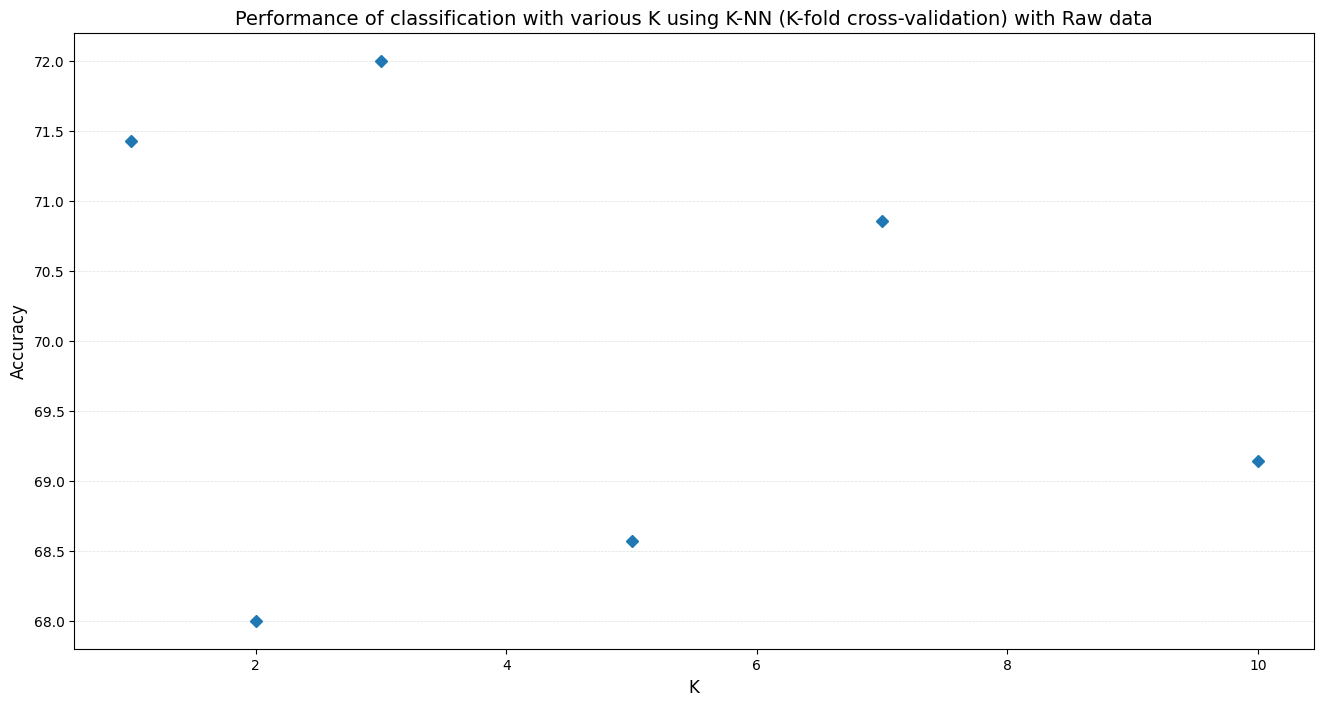

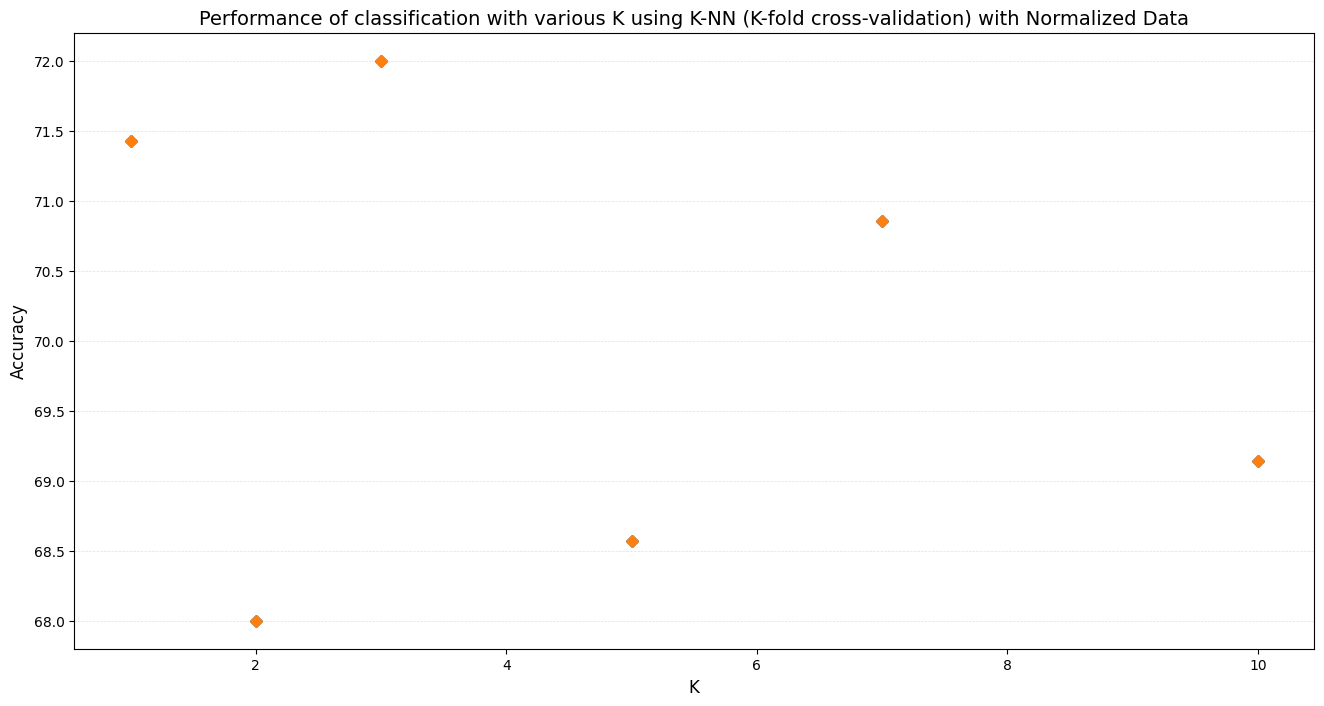

In [26]:
results_nfold = defaultdict(list)

# Les données sont divisées en plusieurs folds 
folds = cross_validation_split(data, n_folds=5)


def creat_graphe_N_Folds_performance(dataSet, nameGraphe, colorGraphe) :
    for k in Ks:
        
        # Listes qui vont contenir les valeurs prédites et les vraies valeurs
        predictions = []
        actuals = []
    
        for test_i in range(len(folds)):
            #print(f"----- Fold = {test_i } - k = {k} -----") 
            
            # train = tout sauf le fold i, qui est utilisé pour tester.
            # Permet de créer une liste à partir des éléments de folds, y compris si c'est vide. 
            train = list(itertools.chain.from_iterable(folds[:test_i] + folds[test_i+1:]))
                
            # test = Fold courrant, utilisé pour tester
            # - complétez - 1 ligne
            test = folds[test_i]
            
            # Effectue la prédiction et l'ajoute au tableau prédictions[] pour chaque element dans test
            # predictions += [...fonction pour faire la classification définie en début de point 2.... for....in ....]
            # - complétez - 1 ligne
            predictions += [predict_classification(train, row, k) for row in test]
            
            # Remplit la liste "actual" avec les valeurs réelles (actuals += ... )
            # - complétez - 1 ligne
            actuals += [row[0] for row in test]
        
        # Mettez le résultat de "accuracy_metric(...,...)" dans results_nfold[k]
        # - complétez - 1 ligne
        results_nfold[k].append(accuracy_metric(actuals, predictions))
        
        print(f'Performance with k={k}: {results_nfold[k]}')
        
    _, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    
    ax.plot(results_nfold.keys(), results_nfold.values(), linestyle='None', marker='D')
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xlabel('K', fontsize=12)
    ax.set_title(nameGraphe, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.4, lw=0.5)


creat_graphe_N_Folds_performance(data, 'Performance of classification with various K using K-NN (K-fold cross-validation) with Raw data', 'darkgreen')
creat_graphe_N_Folds_performance(data_normalized, 'Performance of classification with various K using K-NN (K-fold cross-validation) with Normalized Data', 'blue')

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> Quelle différence dans les code des points 2.2 (validation hold-out et 2.3 (N-Fold cross validation) fait que nous n'avons qu'un seul point par k et non une moyenne et écart-type ? </p>(2 points)

*Réponse:* <br/>
<br/>
Dans le code du point 2.2 la fonction errorbar est utilisée pour afficher le graphique, alors que dans le point 2.3 c'est la fonction plot. <br/>
La fonction errorbar permet d'afficher un graphique avec des coordonnées x, y et une valeur de longueur de la barre à afficher pour chaque point. Dans le cas du point 2.2, le x est la valeur du K-NN utilisée, le y est la moyenne des accuracies obtenues des tests et les barres verticales sont les écarts-type des accuraies obtenues pour chaque K-NN. Egalement une boucle est mise en place pour répéter le tests à nouveau une fois terminés, ce qui rend nécessaire de faire la moyenne des résultats pour chaque K.<br/>
La fonction plot permet d'afficher un simple graphique avec des points de coordonnées x et y. Dans le point 2.2 il n'y à pas de boucle permettant de réaliser des tests plusieurs fois avec le même K et les mêmes données.

---------------------------------

**Différence entre les deux codes et pourquoi N-Fold ne donne qu’un seul point par k**

Dans la **validation hold-out** (point 2.2), le code répète l’expérience plusieurs fois.
À chaque répétition, un nouveau *train-test split* est créé aléatoirement, puis l’accuracy est calculée.
Comme cela est fait dix fois, on obtient **plusieurs valeurs d’accuracy pour chaque k**, ce qui permet ensuite de calculer une **moyenne** et un **écart-type**.

Dans la **validation N-Fold** (point 2.3), le dataset est divisé en folds **une seule fois**, et le modèle est testé une fois sur chaque fold.
Toutes les prédictions sont regroupées, puis **une seule accuracy finale** est calculée pour chaque k.
Le processus n’est pas répété plusieurs fois, il n’y a donc **qu’un seul résultat par k**.


<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font>Les résultats varient-ils d'une exécution à l'autre ? Décrivez le fonctionnement de la N-fold cross validation (point 2.3) en quelques phrases et justifiez votre réponse. </p>(2 points)

*Réponse:* <br/>
<br/>
## Les résultats varient-ils d’une exécution à l’autre ?

Avec la méthode N-fold cross validation, les résultats varient très peu d’une exécution à l’autre. Cela s’explique par le fait que les données sont divisées en folds une seule fois au début. Une fois ces folds créés, ils restent identiques pendant toute l’exécution du programme. Comme il n’y a pas de nouveau tirage aléatoire à chaque test, les calculs sont presque entièrement reproductibles.

## Fonctionnement de la N-fold cross validation

La N-fold cross validation consiste à diviser le dataset en N parties de taille similaire. Pour une valeur donnée de k, le modèle est entraîné sur N−1 folds et testé sur le fold restant. Cette opération est répétée N fois afin que chaque fold soit utilisé une fois comme jeu de test. Toutes les prédictions obtenues sont ensuite regroupées pour calculer une seule accuracy finale.

Comme chaque observation est utilisée exactement une fois pour le test et que la répartition en folds n’est faite qu’une seule fois, la méthode ne dépend presque pas du hasard. C’est pour cette raison que les résultats changent très peu d’une exécution à l’autre, contrairement à la validation hold-out qui repose sur plusieurs séparations aléatoires du dataset.


<a name="Part23pts"></a>
<div class="alert alert-block alert-info">
<b>Corrections Partie 2.3: </b> Points obtenus: /10
</div>

Remarques de l'assistant: 
- code /6
- Q /4


[Début partie 2](#Part2) --- [Table des matières](#toc)

<p style="background-color:#003c9c;padding:3px"><font size="4"><b></b></font></p>



<a name="Part24"></a>
### 2.4 Conclusion
[Début partie 2](#Part2) --- [Table des matières](#toc)



Répondez aux questions suivantes **en faisant des phrases**. 

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font> Quels sont les principaux avantages de l'utilisation des modèles basés sur des règles par rapport à d'autres algorithmes d'apprentissage automatique comme le KNN ? </p>(2 points)

*Réponse:* <br/>
<br/>
Les modèles basés sur des règles présentent plusieurs avantages par rapport à un algorithme comme le KNN.
D'abord, ils sont faciles à interpréter, car les règles sont écrites sous forme de conditions simples que l’on peut comprendre et expliquer directement.
Ils sont également faciles à corriger ou ajuster, puisqu’il suffit de modifier une règle ou un seuil sans avoir à réentraîner un modèle.
Un autre avantage important est qu’ils sont très rapides à exécuter, car la prédiction consiste simplement à vérifier quelques conditions, alors que le KNN doit calculer la distance entre la donnée test et toutes les données d’entraînement, ce qui devient coûteux lorsque le dataset est grand.
Enfin, les modèles basés sur des règles sont généralement moins sensibles à la taille du dataset, car leur temps d’exécution ne dépend pas directement du nombre d’exemples d’entraînement.

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font>Comparez et contrastez les techniques de validation hold-out et de N-Fold Cross Validation dans le contexte de l'évaluation des performances d'un classifieur KNN. </p>(4 points)

*Réponse:* <br/>
<br/>
La validation hold-out consiste à diviser le dataset une seule fois en deux parties : un ensemble d’entraînement et un ensemble de test. Le classifieur KNN est entraîné sur la première partie et évalué sur la seconde. Cette méthode est simple et rapide, mais elle dépend fortement du choix aléatoire du train-test split. Un seul mauvais découpage peut donner une estimation peu représentative de la performance réelle du modèle.
La N-Fold Cross Validation, au contraire, divise les données en N parties (« folds ») et évalue le modèle N fois, chaque fold servant une fois de test. Les performances finales sont obtenues en regroupant les résultats des N itérations. Cette technique utilise toutes les données à la fois pour l’entraînement et pour le test, ce qui donne une estimation beaucoup plus stable et plus fiable de la performance du KNN.
En résumé, la validation hold-out est plus rapide mais moins robuste, tandis que la N-Fold Cross Validation est plus longue à exécuter mais offre une évaluation plus précise et moins sensible au hasard du découpage initial.

<p style="background-color:#AFEEEE;padding:3px"><font size="4"><b>Q </b></font>Comment la nature "lazy learning" du KNN impacte-t-elle ses performances et son efficacité computationnelle par rapport à d'autres algorithmes ? </p>(2 points)

*Réponse:* <br/>
<br/>
Le KNN est un algorithme de type lazy learning, ce qui signifie qu’il ne construit pas de modèle lors de l’entraînement. Toute l'information reste stockée telle quelle dans le dataset. Cette approche rend l’entraînement très rapide, mais elle rend les prédictions beaucoup plus coûteuses : pour classer une nouvelle observation, le KNN doit mesurer la distance entre ce point et toutes les données d’entraînement, ce qui peut devenir très lent lorsque le dataset est grand.
À l’inverse, d’autres algorithmes apprennent un modèle compact pendant l’entraînement (comme les modèles basés sur des règles), ce qui permet d’effectuer les prédictions beaucoup plus rapidement, car ils n'ont pas besoin de parcourir l’ensemble des données à chaque nouvelle prédiction.

<a name="Part24pts"></a>
<div class="alert alert-block alert-info">
<b>Corrections Partie 2.4: </b> Points obtenus: /8
</div>

Remarques de l'assistant: 


[Début partie 2](#Part2) --- [Table des matières](#toc)

<p style="background-color:#003c9c;padding:3px"><font size="4"><b></b></font></p>

Fin